# **Tutorial 3:** Effective Medium Functions
`rokpy` is not limited to predefined models in the `materials.py` module, but the users may use a wide variety of well-known methods and relations in the `effective_medium` module. The methods in this module are raw mathematical relations (python functions) that fall into following categories:
- `bound_methods`
- `contact_methods`
- `inclusion_methods`
- `fluid_methods`
- `empirical_methods`
- `qfactor_methods`

Using these relations (methods), users have more flexibility to build their own models. Table below show the effective medium methods available in `rokpy` package. To learn more about each method, search it in the documentation.


| bound_methods | contact_methods | Inclusion_methods | fluid_methods | empirical_methods |
| --- | --- | --- | --- | --- |
| `hashin_shtrikman_lower()` <br> `hashin_shtrikman_upper()` <br> `hashin_shtrikman_walpole()` <br> `hashin_shtrikman_walpole_lower()` <br> `hashin_shtrikman_walpole_upper()` <br> `modified_hashin_shtrikman()` <br> `modified_voigt_reuss_hill()` <br> `reuss()` <br> `voigt()` <br> `voigt_reuss_hill()` <br> `voigt_reuss_hill_average()`<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/> | `brandt()` <br> `cemented_sand()` <br> `contact_cemented_sand()` <br> `digby()` <br> `hertz_mindlin()` <br> `intermediate_cemented_sand()` <br> `intermediate_sand()` <br> `intermediate_stiff_sand()` <br> `jenkins()` <br> `johnson()` <br> `soft_sand()` <br> `stiff_sand()` <br> `surface_cemented_sand()` <br> `walton_hydrostatic()` <br> `walton_hydrostatic_rough()` <br> `walton_hydrostatic_smooth()` <br> `walton_uniaxial()`<br/><br/><br/><br/> | `dem()` <br> `dem_modified()` <br> `dry_penny_cracks()` <br> `eshelby_cheng()` <br> `hudson()` <br> `kuster_toksoz()` <br> `mori_tanaka()` <br> `self_consistent()`<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/><br/><br/><br/> | `biot()` <br> `biot_high()` <br> `biot_squirt()` <br> `brown_korringa()` <br> `dvorkin()` <br> `gassmann()` <br> `gassmann_biot()` <br> `gassmann_fluidset_substitution()` <br> `gassmann_linear_substitution()` <br> `gassmann_substitution()` <br> `geertsma_smit_high()` <br> `inverse_anisotropic_gassmann()` <br> `inverse_gassmann()` <br> `mavko_jizba_biot()` <br> `mavko_jizba_gurevich()` <br> `mavko_jizba_wetframe()` <br> `marion_bound_average_substitution()`<br/><br/><br/><br/> | `brocher()` <br/> `castagna()` <br/> `eberhart_phillips()` <br/> `gardner()` <br/> `greenberg_castagna_100()` <br/> `greenberg_castagna()` <br/> `geertsma_dryrock()` <br/> `han()` <br/> `krief()` <br/> `krief_dryrock()` <br/> `ludwig()` <br/> `nur_dryclastic()` <br/> `raymer()` <br/> `raymerdvorkin()` <br/> `vernik()` <br/> `vernik_drysandstone()` <br/> `vernik_drysoftsand()` <br/> `vernik_sourcerock()` <br/> `wyllie()` <br/><br/>| 

As an example, in following code block we display different bound methods for a water-saturated sand.

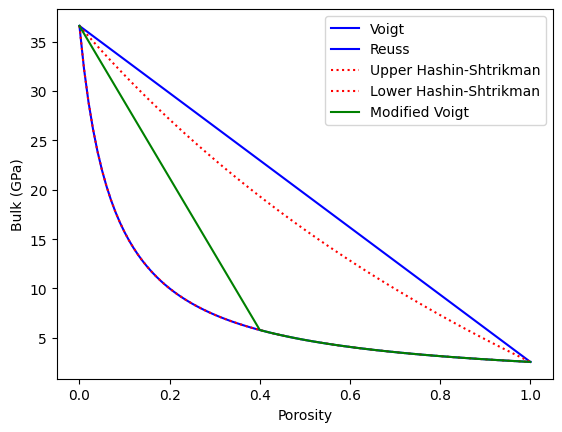

In [ ]:
from rokpy.models import BoundMethods
from rokpy.constants import MineralsPropertyTable, FluidsPropertyTable
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

mineral_props = MineralsPropertyTable()
fluids = FluidsPropertyTable()
phi = np.linspace(0, 1, 101)
phic = 0.4

bulk_modvoigt, shear_modvoigt = BoundMethods.modified_voigt_reuss_hill(mineral_props.Quartz.bulk, mineral_props.Quartz.shear, fluids.Brine.bulk, fluids.Brine.shear, phi, phic, upper_weight=1)
bulk_voigt = BoundMethods.voigt([mineral_props.Quartz.bulk, fluids.Brine.bulk], [1-phi, phi])
bulk_reuss = BoundMethods.reuss([mineral_props.Quartz.bulk, fluids.Brine.bulk], [1-phi, phi])
bulk_hs_lower, _ = BoundMethods.hashin_shtrikman_lower(mineral_props.Quartz.bulk, mineral_props.Quartz.shear, fluids.Brine.bulk, fluids.Brine.shear, phi)
bulk_hs_upper, _ = BoundMethods.hashin_shtrikman_upper(mineral_props.Quartz.bulk, mineral_props.Quartz.shear, fluids.Brine.bulk, fluids.Brine.shear, phi)



plt.figure()
plt.plot(phi, bulk_voigt,'b', phi, bulk_reuss,'b')
plt.plot(phi, bulk_hs_upper, ':r', phi, bulk_hs_lower,':r')
plt.plot(phi, bulk_modvoigt,'g')
plt.legend(["Voigt","Reuss", "Upper Hashin-Shtrikman","Lower Hashin-Shtrikman","Modified Voigt"])
plt.xlabel("Porosity")
plt.ylabel("Bulk (GPa)")
plt.show()


## Build a Model by Raw Methods
Here we are going to build a rock physics model (in our case Xu-White, 1995) using the relations in `methods` module, rather than using the structured `Rock` models in `materials.py` module.



In [ ]:
from rokpy.constants import MineralsPropertyTable, FluidsPropertyTable
from rokpy.effective_medium import BoundMethods, InclusionMethods, FluidEffectMethods, Inclusion, ShapeName
from rokpy.conversions import modulus_to_velocity
import warnings
warnings.filterwarnings('ignore')
import lasio

# Read Las-file
lasfile = r"..\\..\\examples\\wellA.las"
las = lasio.read(lasfile)

# Users may also convert LAS to a DataFrame table which is more convinient 
welllogsdf = las.df().reset_index() #reset_index causes the Depth curve to be treated as a simple log rather than being treated as an index log.

# Extract required well logs from the file
depth = las.depth_m
vp_log = las.curvesdict['VP'].data
vs_log = las.curvesdict['VS'].data
rho_log = las.curvesdict['RHOB'].data
phit_log = las.curvesdict['PHIT'].data
vcly_log = las.curvesdict['VCL'].data
sw_log = las.curvesdict['SW'].data

# Define mineral properties
mineral_props = MineralsPropertyTable()
clay = mineral_props.DryClay
clay.set_properties(27, 7, 2.85)
quartz = mineral_props.Quartz
quartz.set_properties(45, 45, 2.65)

# Define fluid properties
fluid_props = FluidsPropertyTable()
brine = fluid_props.Brine
brine.set_properties(2.37, 0, 1.1)
oil = fluid_props.Oil
oil.set_properties(1.25, 0, 0.45)

clay_inclusion = Inclusion(ShapeName.SPHEROID, 0.07)
quartz_inclusion = Inclusion(ShapeName.SPHEROID, 0.11)
phit = phit_log


# Setup rock model (only elastic properties) by methods in effective_medium module:
Km, Gm = BoundMethods.voigt_reuss_hill([clay.bulk, quartz.bulk], [clay.shear, quartz.shear], [vcly_log, 1-vcly_log], upper_weight=0.5)
Kf, Gf = BoundMethods.voigt_reuss_hill([brine.bulk, oil.bulk], [brine.shear, oil.shear], [sw_log, 1-sw_log], upper_weight=0)
rhom = vcly_log*clay.density + (1 - vcly_log)*quartz.density
rhof = sw_log*brine.density + (1 - sw_log)*oil.density

phi_shale = vcly_log*phit_log
phi_sand = (1 - vcly_log)*phit_log
inclusion_set = {clay_inclusion: phi_shale, quartz_inclusion: phi_sand}

Kdry, Gdry = InclusionMethods.dem(Km, Gm, inclusion_set)
ksat, Gsat = FluidEffectMethods.gassmann(Kdry, Gdry, Km, Kf, phit_log)
rhob = rhom*(1 - phit_log) + rhof*phit_log
Vp, Vs = modulus_to_velocity(ksat, Gsat, rhob)

### Display Results

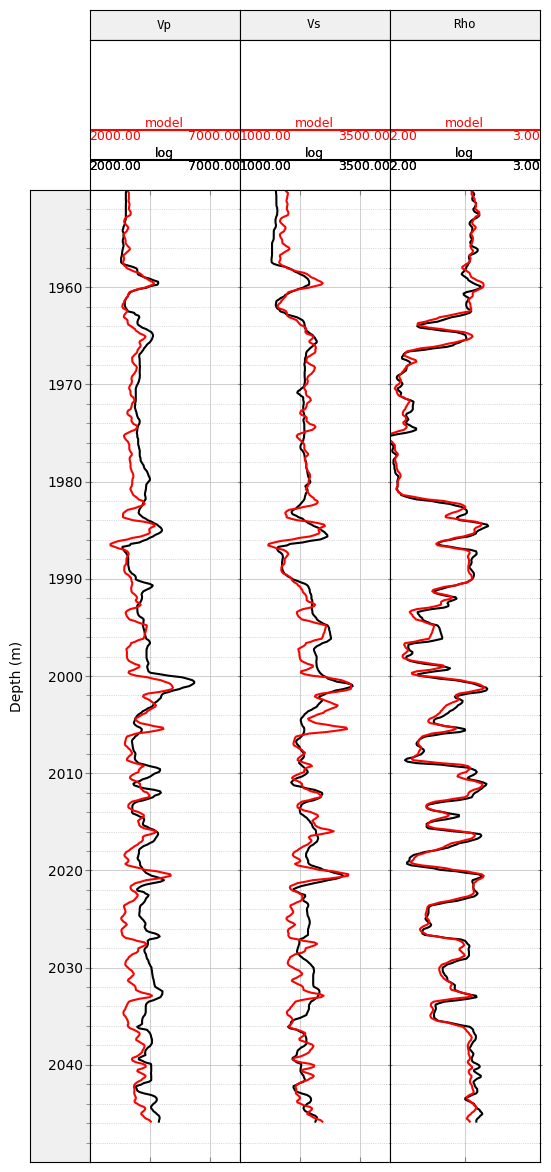

In [9]:
import matplotlib.pyplot as plt
from rokpy.visualization import Sheet
from rokpy.constants import PropertyTemplates

# Define PropertyTemplates
templates = PropertyTemplates()

# Define Log Sheet
sheet = plt.figure(FigureClass=Sheet, figsize=(9, 12))
sheet.set_depth_range(1950,2050)

# Add tracks to the sheet
vp_tr = sheet.add_track(templates.PVelocity)
vs_tr = sheet.add_track(templates.SVelocity)
ro_tr = sheet.add_track(templates.Density)

# Disply each logs on the corresponding tracks
vp_tr.plot(depth, vp_log, label='log')
vs_tr.plot(depth, vs_log, label='log')
ro_tr.plot(depth, rho_log, label='log')

vp_tr.plot(depth, Vp, label='model', color='red')
vs_tr.plot(depth, Vs, label='model', color = 'red')
ro_tr.plot(depth, rhob, label='model', color = 'red')

## Exercise

Try to model the scenarios in following paper by `rokpy` codes:

*Ruiz and Azizov, 2011: Tight shale elastic properties using the soft-porosity and single aspect ratio models*